<a href="https://colab.research.google.com/github/chavezaltamirano-ui/Growth-Models-in-Comparative/blob/main/1Growth_Models_in_Comparative_Perspective.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bloque 0 – Setup

In [31]:
# ============================================
# SETUP: carpetas y librerías básicas
# ============================================

import os
import pandas as pd

os.makedirs("data_raw", exist_ok=True)
os.makedirs("data_clean", exist_ok=True)

Bloque 1 – PWT 11.0 (productividad y crecimiento)

In [32]:
# ============================================
# BLOQUE PWT 11.0 - Productividad y crecimiento
# China (CN) y Estados Unidos (US), 1990–2025
# ============================================

import pandas as pd
import os

os.makedirs('data_raw', exist_ok=True)
os.makedirs('data_clean', exist_ok=True)

# URL del archivo Stata de PWT 11.0 (Dataverse oficial)[web:334]
pwt_url_dta = 'https://dataverse.nl/api/access/datafile/554030'  # Stata file de PWT 11.0

# Leer archivo Stata
pwt_df = pd.read_stata(pwt_url_dta)

# Filtrar China y Estados Unidos, años 1990–2025
countries_names = ['China', 'United States']
pwt_china_us = pwt_df[pwt_df['country'].isin(countries_names)]
pwt_china_us = pwt_china_us[pwt_china_us['year'].between(1990, 2025)]

# Seleccionar variables de productividad y crecimiento[file:311]
cols_pwt = ['country', 'year', 'rgdpna', 'rkna', 'rtfpna', 'hc', 'pop']

missing_cols = [c for c in cols_pwt if c not in pwt_china_us.columns]
if missing_cols:
    print("ADVERTENCIA PWT: estas columnas no se encontraron:", missing_cols)
else:
    pwt_china_us = pwt_china_us[cols_pwt]

# Normalizar identificadores de país a códigos cortos (CN, US)
country_map_pwt = {
    'China': 'CN',
    'United States': 'US'
}
pwt_china_us['country'] = pwt_china_us['country'].map(country_map_pwt)

# Reordenar columnas
pwt_china_us = pwt_china_us[['country', 'year', 'rgdpna', 'rkna', 'rtfpna', 'hc', 'pop']]

print("\nVista previa PWT (China–US, 1990–2025):")
print(pwt_china_us.head())

# Guardar
pwt_raw_path = 'data_raw/pwt_china_us_1990_2025.csv'
pwt_clean_path = 'data_clean/pwt_china_us_1990_2025.csv'

pwt_china_us.to_csv(pwt_raw_path, index=False)
pwt_china_us.to_csv(pwt_clean_path, index=False)

print(f"\nPWT guardado en: {pwt_raw_path}")
print(f"PWT también copiado en: {pwt_clean_path}")


Vista previa PWT (China–US, 1990–2025):
     country  year       rgdpna      rkna    rtfpna        hc          pop
2482      CN  1990  1857144.750  0.036908  0.351905  1.956077  1153.582724
2483      CN  1991  2029162.375  0.039276  0.366076  1.991197  1170.788528
2484      CN  1992  2317807.250  0.043118  0.396038  2.026947  1184.574237
2485      CN  1993  2639603.750  0.048899  0.421519  2.063339  1197.308575
2486      CN  1994  2983718.250  0.055067  0.446154  2.100384  1209.003096

PWT guardado en: data_raw/pwt_china_us_1990_2025.csv
PWT también copiado en: data_clean/pwt_china_us_1990_2025.csv


Bloque 2 – WDI financiero (Banco Mundial)

In [33]:
# ============================================
# BLOQUE WDI FINANCIERO (World Bank)
# China (CN) y Estados Unidos (US), 1990–2025
# ============================================

import pandas as pd
import requests
import os

os.makedirs('data_raw', exist_ok=True)
os.makedirs('data_clean', exist_ok=True)

def download_wdi_indicator(indicator_code, countries, start_year=1990, end_year=2025):
    """
    Descarga un indicador WDI para una lista de países y un rango de años.
    Usa la API del Banco Mundial (JSON).[web:316]
    Devuelve un DataFrame con columnas: country, year, indicator_code.
    """
    frames = []
    for country in countries:
        url = (
            f"http://api.worldbank.org/v2/country/{country}/indicator/{indicator_code}"
            f"?date={start_year}:{end_year}&format=json&per_page=20000"
        )
        resp = requests.get(url)
        if resp.status_code != 200:
            print(f"Error HTTP para {indicator_code}, país {country}: {resp.status_code}")
            continue

        data = resp.json()
        if len(data) < 2 or data[1] is None:
            print(f"Sin datos para {indicator_code}, país {country}")
            continue

        rows = []
        for entry in data[1]:
            year = entry.get('date')
            value = entry.get('value')
            try:
                year_int = int(year)
            except (TypeError, ValueError):
                continue
            rows.append({'country': country, 'year': year_int, indicator_code: value})

        if rows:
            frames.append(pd.DataFrame(rows))

    if frames:
        df = pd.concat(frames, ignore_index=True)
        return df
    else:
        return pd.DataFrame(columns=['country', 'year', indicator_code])

countries = ['CN', 'US']
start_year, end_year = 1990, 2025

indicators_financial = [
    'FS.AST.PRVT.GD.ZS',     # Crédito al sector privado (% PIB)
    'FS.AST.DOMS.GD.ZS',     # Crédito del sector financiero (% PIB)
    'BX.TRF.PWKR.DT.GD.ZS'   # Remesas (% PIB)[web:316]
]

df_fin = None
for ind in indicators_financial:
    print(f"Descargando indicador financiero WDI: {ind}")
    df_ind = download_wdi_indicator(ind, countries, start_year, end_year)
    if df_fin is None:
        df_fin = df_ind
    else:
        df_fin = df_fin.merge(df_ind, on=['country', 'year'], how='outer')

rename_fin = {
    'FS.AST.PRVT.GD.ZS': 'credit_priv_gdp',
    'FS.AST.DOMS.GD.ZS': 'credit_finsec_gdp',
    'BX.TRF.PWKR.DT.GD.ZS': 'remittances_gdp'
}
df_fin = df_fin.rename(columns=rename_fin)
df_fin = df_fin.sort_values(['country', 'year'])

print("\nVista previa WDI financiero:")
print(df_fin.head())

wdi_fin_raw = 'data_raw/wdi_fin_china_us_1990_2025.csv'
wdi_fin_clean = 'data_clean/wdi_fin_china_us_1990_2025.csv'
df_fin.to_csv(wdi_fin_raw, index=False)
df_fin.to_csv(wdi_fin_clean, index=False)

print(f"\nWDI FIN guardado en: {wdi_fin_raw}")
print(f"WDI FIN también copiado en: {wdi_fin_clean}")

Descargando indicador financiero WDI: FS.AST.PRVT.GD.ZS
Descargando indicador financiero WDI: FS.AST.DOMS.GD.ZS
Descargando indicador financiero WDI: BX.TRF.PWKR.DT.GD.ZS

Vista previa WDI financiero:
  country  year  credit_priv_gdp  credit_finsec_gdp  remittances_gdp
0      CN  1990        86.033020                NaN         0.054193
1      CN  1991        88.101074                NaN         0.101381
2      CN  1992        86.053063                NaN         0.144545
3      CN  1993        96.506392                NaN         0.141388
4      CN  1994        85.487555                NaN         0.151165

WDI FIN guardado en: data_raw/wdi_fin_china_us_1990_2025.csv
WDI FIN también copiado en: data_clean/wdi_fin_china_us_1990_2025.csv


/tmp/ipykernel_657/2570008970.py:49: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(frames, ignore_index=True)


Bloque 3 – WDI macro (Banco Mundial)

In [34]:
# ============================================
# BLOQUE WDI MACRO (World Bank)
# China (CN) y Estados Unidos (US), 1990–2025
# PIB, crecimiento, inversión, inflación, apertura, gasto, desempleo, urbanización
# ============================================

import pandas as pd
import requests
import os

os.makedirs('data_raw', exist_ok=True)
os.makedirs('data_clean', exist_ok=True)

# Reutilizamos download_wdi_indicator de la celda anterior
def download_wdi_indicator(indicator_code, countries, start_year=1990, end_year=2025):
    frames = []
    for country in countries:
        url = (
            f"http://api.worldbank.org/v2/country/{country}/indicator/{indicator_code}"
            f"?date={start_year}:{end_year}&format=json&per_page=20000"
        )
        resp = requests.get(url)
        if resp.status_code != 200:
            print(f"Error HTTP para {indicator_code}, país {country}: {resp.status_code}")
            continue

        data = resp.json()
        if len(data) < 2 or data[1] is None:
            print(f"Sin datos para {indicator_code}, país {country}")
            continue

        rows = []
        for entry in data[1]:
            year = entry.get('date')
            value = entry.get('value')
            try:
                year_int = int(year)
            except (TypeError, ValueError):
                continue
            rows.append({'country': country, 'year': year_int, indicator_code: value})

        if rows:
            frames.append(pd.DataFrame(rows))

    if frames:
        df = pd.concat(frames, ignore_index=True)
        return df
    else:
        return pd.DataFrame(columns=['country', 'year', indicator_code])

countries = ['CN', 'US']
start_year, end_year = 1990, 2025

indicators_macro = [
    "NY.GDP.MKTP.KD",      # PIB real (constant 2015 US$)[web:312][web:319]
    "NY.GDP.MKTP.KD.ZG",   # Crecimiento del PIB (%)[web:314]
    "NE.GDI.FTOT.ZS",      # GFCF % PIB[file:311]
    "NE.GDI.FTOT.KD",      # GFCF constante US$
    "FP.CPI.TOTL.ZG",      # Inflación CPI (%)[web:315]
    "NE.TRD.GNFS.ZS",      # Comercio % PIB
    "NE.CON.GOVT.ZS",      # Consumo gobierno % PIB
    "SL.UEM.TOTL.ZS",      # Desempleo %
    "SP.URB.TOTL.IN.ZS",   # Urbanización %
]

df_wdi_macro = None
for ind in indicators_macro:
    print(f"Descargando indicador macro WDI: {ind}")
    df_ind = download_wdi_indicator(ind, countries, start_year, end_year)
    if df_wdi_macro is None:
        df_wdi_macro = df_ind
    else:
        df_wdi_macro = df_wdi_macro.merge(df_ind, on=['country', 'year'], how='outer')

rename_macro = {
    "NY.GDP.MKTP.KD": "gdp_const_usd",
    "NY.GDP.MKTP.KD.ZG": "gdp_growth_pct",
    "NE.GDI.FTOT.ZS": "inv_gfcf_gdp",
    "NE.GDI.FTOT.KD": "inv_gfcf_const_usd",
    "FP.CPI.TOTL.ZG": "inflation_cpi_pct",
    "NE.TRD.GNFS.ZS": "trade_gdp",
    "NE.CON.GOVT.ZS": "gov_cons_gdp",
    "SL.UEM.TOTL.ZS": "unemployment_pct",
    "SP.URB.TOTL.IN.ZS": "urban_pop_pct",
}
df_wdi_macro = df_wdi_macro.rename(columns=rename_macro)
df_wdi_macro = df_wdi_macro.sort_values(["country", "year"])

print("\nVista previa WDI macro:")
print(df_wdi_macro.head())

wdi_macro_raw = "data_raw/wdi_macro_china_us_1990_2025.csv"
wdi_macro_clean = "data_clean/wdi_macro_china_us_1990_2025.csv"
df_wdi_macro.to_csv(wdi_macro_raw, index=False)
df_wdi_macro.to_csv(wdi_macro_clean, index=False)

print(f"\nWDI MACRO guardado en: {wdi_macro_raw}")
print(f"WDI MACRO también copiado en: {wdi_macro_clean}")

Descargando indicador macro WDI: NY.GDP.MKTP.KD
Descargando indicador macro WDI: NY.GDP.MKTP.KD.ZG
Descargando indicador macro WDI: NE.GDI.FTOT.ZS
Descargando indicador macro WDI: NE.GDI.FTOT.KD
Descargando indicador macro WDI: FP.CPI.TOTL.ZG
Descargando indicador macro WDI: NE.TRD.GNFS.ZS
Descargando indicador macro WDI: NE.CON.GOVT.ZS
Descargando indicador macro WDI: SL.UEM.TOTL.ZS
Descargando indicador macro WDI: SP.URB.TOTL.IN.ZS

Vista previa WDI macro:
  country  year  gdp_const_usd  gdp_growth_pct  inv_gfcf_gdp  \
0      CN  1990   1.041178e+12        3.922520     23.942156   
1      CN  1991   1.138795e+12        9.375632     26.033374   
2      CN  1992   1.301616e+12       14.297623     30.615923   
3      CN  1993   1.482880e+12       13.926103     37.310754   
4      CN  1994   1.676881e+12       13.082712     34.694508   

   inv_gfcf_const_usd  inflation_cpi_pct  trade_gdp  gov_cons_gdp  \
0                 NaN           3.052290  24.225982     13.824195   
1             

Bloque 4 – BIS (extracto trimestral + anual)

In [35]:
# ============================================
# BLOQUE BIS - Crédito al sector no financiero
# Extracto trimestral + anual CN/US 1990–2025
# ============================================

import pandas as pd
import requests
import os

os.makedirs('data_raw', exist_ok=True)
os.makedirs('data_clean', exist_ok=True)

bis_xlsx_path = "data_raw/totcredit.xlsx"

# Descargar el Excel BIS si no existe
if not os.path.exists(bis_xlsx_path):
    bis_xlsx_url = "https://www.bis.org/statistics/totcredit/totcredit.xlsx"
    print("Descargando totcredit.xlsx desde BIS...")
    resp_bis = requests.get(bis_xlsx_url)
    if resp_bis.status_code != 200:
        raise RuntimeError(f"Error al descargar totcredit.xlsx: HTTP {resp_bis.status_code}")
    with open(bis_xlsx_path, "wb") as f:
        f.write(resp_bis.content)
    print("Descarga BIS completada.")
else:
    print("totcredit.xlsx ya existe en data_raw; usando el existente.")

# Leer 'Quarterly Series'
xls = pd.ExcelFile(bis_xlsx_path)
print("Hojas disponibles en totcredit.xlsx:", xls.sheet_names)

sheet_q = "Quarterly Series"
df_q_raw = pd.read_excel(bis_xlsx_path, sheet_name=sheet_q, header=None)

print("\nDimensiones 'Quarterly Series':", df_q_raw.shape)
print("Primeras filas (referencia):")
print(df_q_raw.iloc[:5, :10])

# Metadatos de columnas
meta_list = []
for j in range(1, df_q_raw.shape[1]):
    header = df_q_raw.iloc[0, j]
    unit   = df_q_raw.iloc[1, j]
    area   = df_q_raw.iloc[2, j]
    code   = df_q_raw.iloc[3, j]
    meta_list.append({
        "col_index": j,
        "header": str(header),
        "unit": str(unit),
        "area": str(area),
        "code": str(code),
    })
meta = pd.DataFrame(meta_list)

mask_china = meta["header"].str.contains("China", case=False, na=False)
mask_us    = meta["header"].str.contains("United States", case=False, na=False)
mask_pct   = meta["header"].str.contains("Percentage of GDP", case=False, na=False)

meta_china_pct = meta[mask_china & mask_pct]
meta_us_pct    = meta[mask_us & mask_pct]

print("\nColumnas BIS China (% PIB):")
print(meta_china_pct)

print("\nColumnas BIS US (% PIB):")
print(meta_us_pct)

# Fechas y extracción de series
date_raw = df_q_raw.iloc[:, 0]
mask_date = ~date_raw.isna() & \
            ~date_raw.astype(str).str.contains("Back to menu", case=False, na=False) & \
            ~date_raw.astype(str).str.contains("Period", case=False, na=False)

date_clean = date_raw[mask_date]
dates = pd.to_datetime(date_clean, errors="coerce")
valid_idx = date_clean.index

df_bis_extracted = pd.DataFrame({"date": dates})

# Añadir columnas China
for _, row in meta_china_pct.iterrows():
    j = row["col_index"]
    col_name = f"CN_{row['code']}"
    values = df_q_raw.iloc[valid_idx, j].reset_index(drop=True)
    df_bis_extracted[col_name] = values

# Añadir columnas Estados Unidos
for _, row in meta_us_pct.iterrows():
    j = row["col_index"]
    col_name = f"US_{row['code']}"
    values = df_q_raw.iloc[valid_idx, j].reset_index(drop=True)
    df_bis_extracted[col_name] = values

print("\nVista previa BIS extracto (trimestral):")
print(df_bis_extracted.head())

bis_extract_raw = "data_raw/bis_totcredit_extract_cn_us.csv"
bis_extract_clean = "data_clean/bis_totcredit_extract_cn_us.csv"
df_bis_extracted.to_csv(bis_extract_raw, index=False)
df_bis_extracted.to_csv(bis_extract_clean, index=False)

print(f"\nBIS EXTRACTO guardado en: {bis_extract_raw}")
print(f"BIS EXTRACTO también copiado en: {bis_extract_clean}")

# ---- BIS anual ----

extract_path = bis_extract_clean if os.path.exists(bis_extract_clean) else bis_extract_raw
df_q = pd.read_csv(extract_path)

df_q["date"] = pd.to_datetime(df_q["date"], errors="coerce")
df_q = df_q.dropna(subset=["date"])
df_q["year"] = df_q["date"].dt.year
df_q = df_q[(df_q["year"] >= 1990) & (df_q["year"] <= 2025)]

col_map = {
    # China
    "CN_Q:CN:C:A:M:770:A": ("CN", "bis_tot_credit_gdp"),
    "CN_Q:CN:P:A:M:770:A": ("CN", "bis_pvt_credit_gdp"),
    "CN_Q:CN:H:A:M:770:A": ("CN", "bis_hh_credit_gdp"),
    "CN_Q:CN:N:A:M:770:A": ("CN", "bis_nfc_credit_gdp"),
    "CN_Q:CN:G:A:N:770:A": ("CN", "bis_gov_credit_gdp"),
    "CN_Q:CN:P:B:M:770:A": ("CN", "bis_pvt_banks_credit_gdp"),

    # Estados Unidos
    "US_Q:US:C:A:M:770:A": ("US", "bis_tot_credit_gdp"),
    "US_Q:US:P:A:M:770:A": ("US", "bis_pvt_credit_gdp"),
    "US_Q:US:H:A:M:770:A": ("US", "bis_hh_credit_gdp"),
    "US_Q:US:N:A:M:770:A": ("US", "bis_nfc_credit_gdp"),
    "US_Q:US:G:A:N:770:A": ("US", "bis_gov_credit_gdp"),
    "US_Q:US:P:B:M:770:A": ("US", "bis_pvt_banks_credit_gdp"),
}

records = []
for col in df_q.columns:
    if col in ["date", "year"]:
        continue
    if col not in col_map:
        continue

    country, series_short = col_map[col]
    series_values = df_q[col].values
    dates = df_q["date"].values
    years = df_q["year"].values

    for dt, yr, val in zip(dates, years, series_values):
        records.append({
            "country": country,
            "year": yr,
            "date": dt,
            "series_short": series_short,
            "value": val,
        })

df_long = pd.DataFrame(records)
df_long = (
    df_long
    .sort_values(["country", "series_short", "year", "date"])
    .groupby(["country", "series_short", "year"], as_index=False)
    .tail(1)
)

df_bis_annual = (
    df_long
    .pivot(index=["country", "year"], columns="series_short", values="value")
    .reset_index()
)
df_bis_annual = df_bis_annual.sort_values(["country", "year"])

print("\nVista previa BIS anual:")
print(df_bis_annual.head())

bis_annual_raw = "data_raw/bis_totcredit_cn_us_1990_2025.csv"
bis_annual_clean = "data_clean/bis_totcredit_cn_us_1990_2025.csv"
df_bis_annual.to_csv(bis_annual_raw, index=False)
df_bis_annual.to_csv(bis_annual_clean, index=False)

print(f"\nBIS ANUAL guardado en: {bis_annual_raw}")
print(f"BIS ANUAL también copiado en: {bis_annual_clean}")

totcredit.xlsx ya existe en data_raw; usando el existente.
Hojas disponibles en totcredit.xlsx: ['Content', 'Summary Documentation', 'Quarterly Series']

Dimensiones 'Quarterly Series': (337, 1134)
Primeras filas (referencia):
                     0                                                  1  \
0         Back to menu  Emerging market economies (aggregate) - Credit...   
1                  NaN                                   Per cent (Units)   
2                  NaN              Emerging market economies (aggregate)   
3               Period                                   Q:4T:C:A:M:770:A   
4  1940-06-30 00:00:00                                                NaN   

                                                   2  \
0  Emerging market economies (aggregate) - Credit...   
1                                   Per cent (Units)   
2              Emerging market economies (aggregate)   
3                                   Q:4T:C:A:M:799:A   
4                             

Bloque 5 – Merge maestro

In [36]:
# ============================================
# BLOQUE MERGE MAESTRO
# Panel CN/US 1990–2025: PWT + WDI macro + WDI financiero + BIS
# ============================================

import pandas as pd
import os

pwt_path       = "data_clean/pwt_china_us_1990_2025.csv"
wdi_macro_path = "data_clean/wdi_macro_china_us_1990_2025.csv"
wdi_fin_path   = "data_clean/wdi_fin_china_us_1990_2025.csv"
bis_path       = "data_clean/bis_totcredit_cn_us_1990_2025.csv"

for path in [pwt_path, wdi_macro_path, wdi_fin_path, bis_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"No se encontró el archivo esperado: {path}")

df_pwt       = pd.read_csv(pwt_path)
df_wdi_macro = pd.read_csv(wdi_macro_path)
df_wdi_fin   = pd.read_csv(wdi_fin_path)
df_bis       = pd.read_csv(bis_path)

for df in [df_pwt, df_wdi_macro, df_wdi_fin, df_bis]:
    df.sort_values(["country", "year"], inplace=True)

df_panel = df_pwt.copy()
df_panel = df_panel.merge(df_wdi_macro, on=["country", "year"], how="left")
df_panel = df_panel.merge(df_wdi_fin,   on=["country", "year"], how="left")
df_panel = df_panel.merge(df_bis,       on=["country", "year"], how="left")

df_panel = df_panel.sort_values(["country", "year"])

print("\nVista rápida del panel combinado (primeras filas):")
print(df_panel.head())

print("\nVista rápida del panel combinado (últimas filas):")
print(df_panel.tail())

print("\nNúmero de columnas en el panel:", df_panel.shape[1])

panel_raw_path   = "data_raw/china_us_panel_1990_2025.csv"
panel_clean_path = "data_clean/china_us_panel_1990_2025.csv"

df_panel.to_csv(panel_raw_path, index=False)
df_panel.to_csv(panel_clean_path, index=False)

print(f"\nPANEL guardado en: {panel_raw_path}")
print(f"PANEL también copiado en: {panel_clean_path}")


Vista rápida del panel combinado (primeras filas):
  country  year     rgdpna      rkna    rtfpna        hc          pop  \
0      CN  1990  1857144.8  0.036908  0.351905  1.956077  1153.582724   
1      CN  1991  2029162.4  0.039276  0.366076  1.991197  1170.788528   
2      CN  1992  2317807.2  0.043118  0.396038  2.026947  1184.574237   
3      CN  1993  2639603.8  0.048899  0.421519  2.063338  1197.308575   
4      CN  1994  2983718.2  0.055067  0.446154  2.100384  1209.003096   

   gdp_const_usd  gdp_growth_pct  inv_gfcf_gdp  ...  urban_pop_pct  \
0   1.041178e+12        3.922520     23.942156  ...      26.195702   
1   1.138795e+12        9.375632     26.033374  ...      26.940247   
2   1.301616e+12       14.297623     30.615923  ...      27.459869   
3   1.482880e+12       13.926103     37.310754  ...      27.990076   
4   1.676881e+12       13.082712     34.694508  ...      28.509804   

   credit_priv_gdp  credit_finsec_gdp  remittances_gdp  bis_gov_credit_gdp  \
0        8

In [41]:
# ============================================
# BLOQUE INFORME - Estado de los datos descargados
# Revisa PWT, WDI macro, WDI financiero, BIS, Panel
# ============================================

import os
import pandas as pd

print("=== Archivos en data_clean ===")
if os.path.isdir("data_clean"):
    for f in os.listdir("data_clean"):
        print(f)
else:
    print("La carpeta data_clean no existe.")

def resumen_csv(path, nombre):
    if not os.path.exists(path):
        print(f"\n[{nombre}] NO ENCONTRADO en {path}")
        return
    df = pd.read_csv(path)
    print(f"\n--- {nombre} ---")
    print(f"Archivo: {path}")
    print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
    if "year" in df.columns:
        print(f"Años (min-max): {df['year'].min()} - {df['year'].max()}")
    if "country" in df.columns:
        print(f"Países presentes: {df['country'].unique().tolist()}")
    print("Columnas principales (primeras 15):")
    print(df.columns[:15])
    print("Vista rápida (head):")
    print(df.head())

# 1. PWT
resumen_csv("data_clean/pwt_china_us_1990_2025.csv", "PWT 11.0 (productividad y crecimiento)")

# 2. WDI macro
resumen_csv("data_clean/wdi_macro_china_us_1990_2025.csv", "WDI macro (PIB, inversión, inflación, etc.)")

# 3. WDI financiero
resumen_csv("data_clean/wdi_fin_china_us_1990_2025.csv", "WDI financiero (crédito privado, remesas, etc.)")

# 4. BIS anual
resumen_csv("data_clean/bis_totcredit_cn_us_1990_2025.csv", "BIS anual (crédito total, privado, hogares, corporaciones, gobierno, bancos)")

# 5. Panel final (si ya corriste el merge maestro)
resumen_csv("data_clean/china_us_panel_1990_2025.csv", "Panel CN/US 1990–2025 (PWT + WDI + BIS)")

=== Archivos en data_clean ===
bis_totcredit_cn_us_1990_2025.csv
china_us_panel_1990_2025.csv
wdi_fin_china_us_1990_2025.csv
weo_gov_debt_cn_us_2017_2026.csv
bis_totcredit_extract_cn_us.csv
wdi_macro_china_us_1990_2025.csv
pwt_china_us_1990_2025.csv

--- PWT 11.0 (productividad y crecimiento) ---
Archivo: data_clean/pwt_china_us_1990_2025.csv
Dimensiones: 68 filas x 7 columnas
Años (min-max): 1990 - 2023
Países presentes: ['CN', 'US']
Columnas principales (primeras 15):
Index(['country', 'year', 'rgdpna', 'rkna', 'rtfpna', 'hc', 'pop'], dtype='object')
Vista rápida (head):
  country  year     rgdpna      rkna    rtfpna        hc          pop
0      CN  1990  1857144.8  0.036908  0.351905  1.956077  1153.582724
1      CN  1991  2029162.4  0.039276  0.366076  1.991197  1170.788528
2      CN  1992  2317807.2  0.043118  0.396038  2.026947  1184.574237
3      CN  1993  2639603.8  0.048899  0.421519  2.063338  1197.308575
4      CN  1994  2983718.2  0.055067  0.446154  2.100384  1209.003096


IMF – Global Debt Database / WEO
5.2. WEO – Government gross debt

In [42]:
# 5.2 WEO – Government gross debt (GGXWDG_NGDP)
# Crear panel gov_debt_gdp para CN y US, 2017–2026

import os
import pandas as pd

os.makedirs("data_clean", exist_ok=True)

# Si el archivo subido tiene doble extensión, renombrarlo
if os.path.exists("weo_gov_debt_cn_us.csv.csv") and not os.path.exists("weo_gov_debt_cn_us.csv"):
    os.rename("weo_gov_debt_cn_us.csv.csv", "weo_gov_debt_cn_us.csv")

# Cargar el dump WEO con GGXWDG_NGDP
df_weo = pd.read_csv("weo_gov_debt_cn_us.csv")

# Filtrar solo las series GGXWDG_NGDP (% of GDP)
mask_pct = df_weo["SERIES_CODE"].str.contains("GGXWDG_NGDP", na=False)
df_pct = df_weo[mask_pct].copy()

# Separar China y Estados Unidos
mask_cn = df_pct["SERIES_CODE"].str.startswith("CHN.")
mask_us = df_pct["SERIES_CODE"].str.startswith("USA.")

df_cn = df_pct[mask_cn].copy()
df_us = df_pct[mask_us].copy()

print("China (GGXWDG_NGDP) filas:", df_cn.shape[0])
print(df_cn[["SERIES_CODE", "COUNTRY"]].head())
print("US (GGXWDG_NGDP) filas:", df_us.shape[0])
print(df_us[["SERIES_CODE", "COUNTRY"]].head())

# Función: ancho (años en columnas) -> largo (year, gov_debt_gdp)
def wide_to_long_weo(df_country, country_code):
    year_cols = [c for c in df_country.columns if c.isdigit()]
    sub = df_country[year_cols].copy()
    sub = sub.T.reset_index()
    sub.columns = ["year", "gov_debt_gdp"]
    sub["year"] = sub["year"].astype(int)
    sub["country"] = country_code
    return sub[["country", "year", "gov_debt_gdp"]]

df_cn_long = wide_to_long_weo(df_cn, "CN")
df_us_long = wide_to_long_weo(df_us, "US")

gov_debt_panel = (
    pd.concat([df_cn_long, df_us_long], ignore_index=True)
    .sort_values(["country", "year"])
)

print("\nPanel WEO gov_debt_gdp CN/US:")
print(gov_debt_panel.head())
print(gov_debt_panel.tail())

out_path = "data_clean/weo_gov_debt_cn_us_2017_2026.csv"
gov_debt_panel.to_csv(out_path, index=False)
print(f"\nGuardado: {out_path}")

China (GGXWDG_NGDP) filas: 1
            SERIES_CODE                      COUNTRY
7335  CHN.GGXWDG_NGDP.A  China, People's Republic of
US (GGXWDG_NGDP) filas: 1
          SERIES_CODE        COUNTRY
52  USA.GGXWDG_NGDP.A  United States

Panel WEO gov_debt_gdp CN/US:
  country  year  gov_debt_gdp
0      CN  2017        53.891
1      CN  2018        55.875
2      CN  2019        59.838
3      CN  2020        70.134
4      CN  2021        72.131
   country  year  gov_debt_gdp
15      US  2022       119.145
16      US  2023       119.963
17      US  2024       122.270
18      US  2025       123.886
19      US  2026       125.781

Guardado: data_clean/weo_gov_debt_cn_us_2017_2026.csv


Bloque 6 –Merge Maestro

In [43]:
# 6. Merge panel macro CN–US con WEO gov_debt_gdp

import pandas as pd

macro_panel = pd.read_csv("data_clean/china_us_panel_1990_2025.csv")
gov_debt_weo = pd.read_csv("data_clean/weo_gov_debt_cn_us_2017_2026.csv")

macro_with_weo_debt = macro_panel.merge(
    gov_debt_weo,
    on=["country", "year"],
    how="left"
)

out_path = "data_clean/china_us_panel_1990_2025_with_weo_govdebt.csv"
macro_with_weo_debt.to_csv(out_path, index=False)
print(f"Panel macro con WEO gov_debt_gdp guardado en: {out_path}")

Panel macro con WEO gov_debt_gdp guardado en: data_clean/china_us_panel_1990_2025_with_weo_govdebt.csv


In [44]:
import pandas as pd

panel = pd.read_csv("data_clean/china_us_panel_1990_2025_with_weo_govdebt.csv")
print(panel.columns)
print(panel.head())
print(panel[panel["country"] == "US"].tail())

Index(['country', 'year', 'rgdpna', 'rkna', 'rtfpna', 'hc', 'pop',
       'gdp_const_usd', 'gdp_growth_pct', 'inv_gfcf_gdp', 'inv_gfcf_const_usd',
       'inflation_cpi_pct', 'trade_gdp', 'gov_cons_gdp', 'unemployment_pct',
       'urban_pop_pct', 'credit_priv_gdp', 'credit_finsec_gdp',
       'remittances_gdp', 'bis_gov_credit_gdp', 'bis_hh_credit_gdp',
       'bis_nfc_credit_gdp', 'bis_pvt_banks_credit_gdp', 'bis_pvt_credit_gdp',
       'bis_tot_credit_gdp', 'gov_debt_gdp'],
      dtype='object')
  country  year     rgdpna      rkna    rtfpna        hc          pop  \
0      CN  1990  1857144.8  0.036908  0.351905  1.956077  1153.582724   
1      CN  1991  2029162.4  0.039276  0.366076  1.991197  1170.788528   
2      CN  1992  2317807.2  0.043118  0.396038  2.026947  1184.574237   
3      CN  1993  2639603.8  0.048899  0.421519  2.063338  1197.308575   
4      CN  1994  2983718.2  0.055067  0.446154  2.100384  1209.003096   

   gdp_const_usd  gdp_growth_pct  inv_gfcf_gdp  ...  cred

Bloque 10, – Gráficos de inversión vs. crédito (CN vs US)

Columnas disponibles en el panel:
Index(['country', 'year', 'rgdpna', 'rkna', 'rtfpna', 'hc', 'pop',
       'gdp_const_usd', 'gdp_growth_pct', 'inv_gfcf_gdp', 'inv_gfcf_const_usd',
       'inflation_cpi_pct', 'trade_gdp', 'gov_cons_gdp', 'unemployment_pct',
       'urban_pop_pct', 'credit_priv_gdp', 'credit_finsec_gdp',
       'remittances_gdp', 'bis_gov_credit_gdp', 'bis_hh_credit_gdp',
       'bis_nfc_credit_gdp', 'bis_pvt_banks_credit_gdp', 'bis_pvt_credit_gdp',
       'bis_tot_credit_gdp'],
      dtype='object')


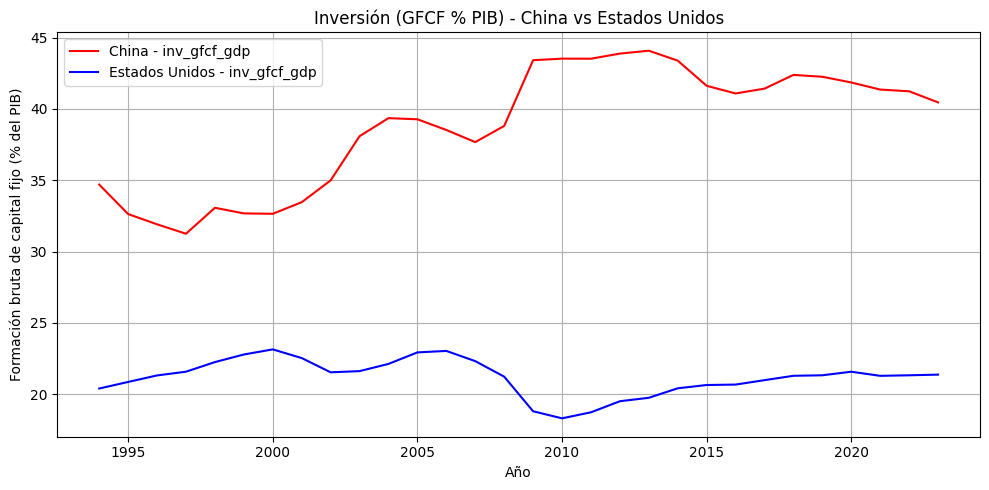

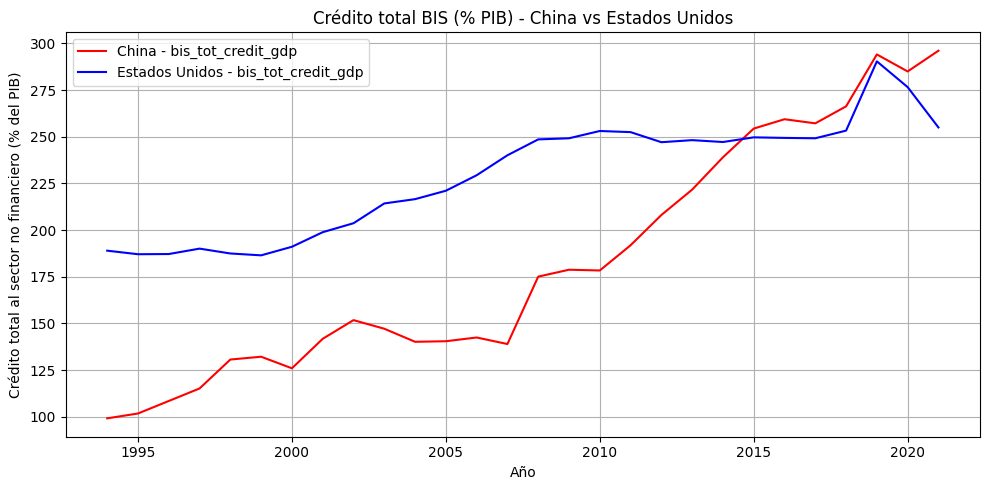

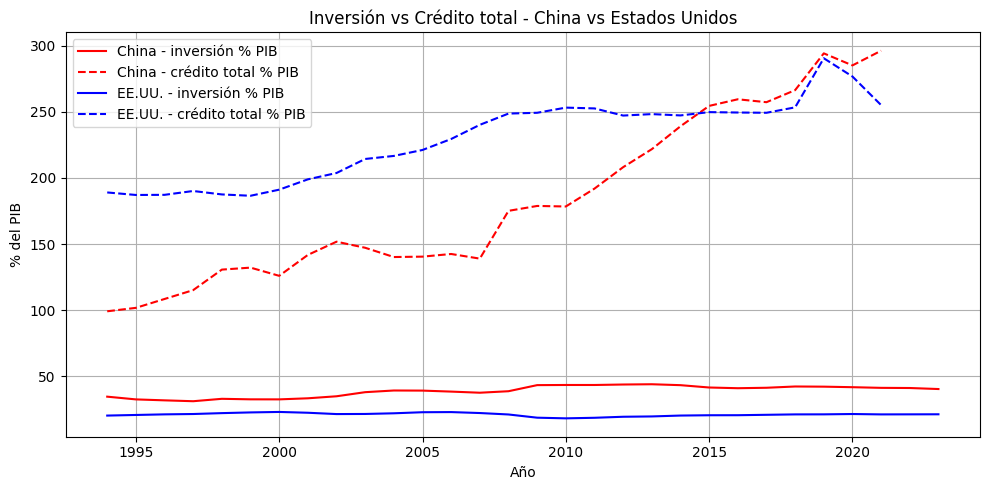

In [38]:
# ============================================
# BLOQUE GRÁFICOS - Inversión vs Crédito (CN vs US)
# Usa china_us_panel_1990_2025.csv
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import os

panel_path = "data_clean/china_us_panel_1990_2025.csv"
if not os.path.exists(panel_path):
    raise FileNotFoundError(f"No se encontró el panel en {panel_path}")

df_panel = pd.read_csv(panel_path)

# Opcional: restringir a rango con más datos completos (por ejemplo 1994–2023)
df_panel = df_panel[df_panel["year"].between(1994, 2023)]

# Separar China y Estados Unidos
cn = df_panel[df_panel["country"] == "CN"].copy()
us = df_panel[df_panel["country"] == "US"].copy()

# Comprobación rápida de columnas disponibles
print("Columnas disponibles en el panel:")
print(df_panel.columns)

# ============================================
# Gráfico 1: Inversión (GFCF % PIB) en CN y US
# ============================================

plt.figure(figsize=(10, 5))
plt.plot(cn["year"], cn["inv_gfcf_gdp"], label="China - inv_gfcf_gdp", color="red")
plt.plot(us["year"], us["inv_gfcf_gdp"], label="Estados Unidos - inv_gfcf_gdp", color="blue")
plt.xlabel("Año")
plt.ylabel("Formación bruta de capital fijo (% del PIB)")
plt.title("Inversión (GFCF % PIB) - China vs Estados Unidos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# Gráfico 2: Crédito total BIS (% PIB) en CN y US
# ============================================

plt.figure(figsize=(10, 5))
plt.plot(cn["year"], cn["bis_tot_credit_gdp"], label="China - bis_tot_credit_gdp", color="red")
plt.plot(us["year"], us["bis_tot_credit_gdp"], label="Estados Unidos - bis_tot_credit_gdp", color="blue")
plt.xlabel("Año")
plt.ylabel("Crédito total al sector no financiero (% del PIB)")
plt.title("Crédito total BIS (% PIB) - China vs Estados Unidos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# Gráfico 3 (opcional): Inversión vs crédito en un mismo eje
# ============================================

plt.figure(figsize=(10, 5))
plt.plot(cn["year"], cn["inv_gfcf_gdp"], label="China - inversión % PIB", color="red", linestyle="-")
plt.plot(cn["year"], cn["bis_tot_credit_gdp"], label="China - crédito total % PIB", color="red", linestyle="--")
plt.plot(us["year"], us["inv_gfcf_gdp"], label="EE.UU. - inversión % PIB", color="blue", linestyle="-")
plt.plot(us["year"], us["bis_tot_credit_gdp"], label="EE.UU. - crédito total % PIB", color="blue", linestyle="--")
plt.xlabel("Año")
plt.ylabel("% del PIB")
plt.title("Inversión vs Crédito total - China vs Estados Unidos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
import os

print("data_clean:", os.listdir("data_clean"))
print("data_raw:", os.listdir("data_raw"))

data_clean: ['bis_totcredit_cn_us_1990_2025.csv', 'china_us_panel_1990_2025.csv', 'china_us_panel_1990_2025_with_weo_govdebt.csv', 'wdi_fin_china_us_1990_2025.csv', 'weo_gov_debt_cn_us_2017_2026.csv', 'bis_totcredit_extract_cn_us.csv', 'wdi_macro_china_us_1990_2025.csv', 'pwt_china_us_1990_2025.csv']
data_raw: ['bis_totcredit_cn_us_1990_2025.csv', 'china_us_panel_1990_2025.csv', 'wdi_fin_china_us_1990_2025.csv', 'totcredit.xlsx', 'bis_totcredit_extract_cn_us.csv', 'wdi_macro_china_us_1990_2025.csv', 'pwt_china_us_1990_2025.csv']


In [47]:
import os
print(os.listdir("."))

['.config', 'data_raw', 'weo_gov_debt_cn_us.csv', 'data_clean', 'sample_data']


In [48]:
from google.colab import files
uploaded = files.upload()

Saving imf_gdd_debt_cn_us_1990_2024.csv to imf_gdd_debt_cn_us_1990_2024.csv


In [49]:
import os
import shutil

os.makedirs("data_clean", exist_ok=True)

for fname in uploaded.keys():
    shutil.move(fname, f"data_clean/{fname}")
    print("Movido a data_clean:", fname)

Movido a data_clean: imf_gdd_debt_cn_us_1990_2024.csv


In [50]:
import os
print("data_clean:", os.listdir("data_clean"))

data_clean: ['imf_gdd_debt_cn_us_1990_2024.csv', 'bis_totcredit_cn_us_1990_2025.csv', 'china_us_panel_1990_2025.csv', 'china_us_panel_1990_2025_with_weo_govdebt.csv', 'wdi_fin_china_us_1990_2025.csv', 'weo_gov_debt_cn_us_2017_2026.csv', 'bis_totcredit_extract_cn_us.csv', 'wdi_macro_china_us_1990_2025.csv', 'pwt_china_us_1990_2025.csv']


In [52]:
import pandas as pd

macro = pd.read_csv("data_clean/china_us_panel_1990_2025_with_weo_govdebt.csv")
gdd   = pd.read_csv("data_clean/imf_gdd_debt_cn_us_1990_2024.csv")

panel_macro_gdd = macro.merge(
    gdd,
    on=["country", "year"],
    how="left"
)

panel_macro_gdd.to_csv(
    "data_clean/china_us_panel_1990_2025_with_weo_gdd.csv",
    index=False
)

In [53]:
['bis_totcredit_cn_us_1990_2025.csv',
 'bis_totcredit_extract_cn_us.csv',
 'china_us_panel_1990_2025.csv',
 'china_us_panel_1990_2025_with_weo_govdebt.csv',
 'wdi_fin_china_us_1990_2025.csv',
 'wdi_macro_china_us_1990_2025.csv',
 'pwt_china_us_1990_2025.csv',
 'weo_gov_debt_cn_us_2017_2026.csv',
 'imf_gdd_debt_cn_us_1990_2024.csv', ...]

['bis_totcredit_cn_us_1990_2025.csv',
 'bis_totcredit_extract_cn_us.csv',
 'china_us_panel_1990_2025.csv',
 'china_us_panel_1990_2025_with_weo_govdebt.csv',
 'wdi_fin_china_us_1990_2025.csv',
 'wdi_macro_china_us_1990_2025.csv',
 'pwt_china_us_1990_2025.csv',
 'weo_gov_debt_cn_us_2017_2026.csv',
 'imf_gdd_debt_cn_us_1990_2024.csv',
 Ellipsis]

In [59]:
from google.colab import files
uploaded = files.upload()

Saving API_SL.GDP.PCAP.EM.KD_DS2_en_csv_v2_34776[1].csv to API_SL.GDP.PCAP.EM.KD_DS2_en_csv_v2_34776[1] (1).csv


In [57]:
import os
import shutil

os.makedirs("data_raw", exist_ok=True)

for fname in uploaded.keys():
    shutil.move(fname, f"data_raw/{fname}")
    print("Movido a data_raw:", fname)

Movido a data_raw: Metadata_Indicator_API_SL.GDP.PCAP.EM.KD_DS2_en_csv_v2_34776[1].csv


In [61]:
import os

print("Raíz:", os.listdir("."))
if os.path.exists("data_raw"):
    print("data_raw:", os.listdir("data_raw"))

Raíz: ['.config', 'data_raw', 'API_SL.GDP.PCAP.EM.KD_DS2_en_csv_v2_34776.csv', '.ipynb_checkpoints', 'Metadata_Country_API_SL.GDP.PCAP.EM.KD_DS2_en_csv_v2_34776[1].csv', 'weo_gov_debt_cn_us.csv', 'data_clean', 'sample_data']
data_raw: ['bis_totcredit_cn_us_1990_2025.csv', 'china_us_panel_1990_2025.csv', 'wdi_fin_china_us_1990_2025.csv', 'Metadata_Indicator_API_SL.GDP.PCAP.EM.KD_DS2_en_csv_v2_34776[1].csv', 'totcredit.xlsx', 'bis_totcredit_extract_cn_us.csv', 'wdi_macro_china_us_1990_2025.csv', 'pwt_china_us_1990_2025.csv']


In [62]:
import shutil

os.makedirs("data_raw", exist_ok=True)

shutil.move(
    "API_SL.GDP.PCAP.EM.KD_DS2_en_csv_v2_34776.csv",
    "data_raw/API_SL.GDP.PCAP.EM.KD_DS2_en_csv_v2_34776.csv"
)

print("data_raw:", os.listdir("data_raw"))

data_raw: ['bis_totcredit_cn_us_1990_2025.csv', 'API_SL.GDP.PCAP.EM.KD_DS2_en_csv_v2_34776.csv', 'china_us_panel_1990_2025.csv', 'wdi_fin_china_us_1990_2025.csv', 'Metadata_Indicator_API_SL.GDP.PCAP.EM.KD_DS2_en_csv_v2_34776[1].csv', 'totcredit.xlsx', 'bis_totcredit_extract_cn_us.csv', 'wdi_macro_china_us_1990_2025.csv', 'pwt_china_us_1990_2025.csv']


In [63]:
import pandas as pd

file_lp = "data_raw/API_SL.GDP.PCAP.EM.KD_DS2_en_csv_v2_34776.csv"

wdi_lp_raw = pd.read_csv(file_lp, skiprows=4)

print("Columnas:", wdi_lp_raw.columns)
print(wdi_lp_raw.head())

Columnas: Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='object')
                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

          

In [64]:
import os
import pandas as pd

os.makedirs("data_clean", exist_ok=True)

# 1. Leemos el archivo WDI ya localizado
file_lp = "data_raw/API_SL.GDP.PCAP.EM.KD_DS2_en_csv_v2_34776.csv"

wdi_lp_raw = pd.read_csv(file_lp, skiprows=4)

# 2. Filtrar solo China y EE.UU. por código
mask = wdi_lp_raw["Country Code"].isin(["CHN", "USA"])
wdi_lp = wdi_lp_raw[mask].copy()

# 3. Identificar columnas de año (todas las que son dígitos)
year_cols = [c for c in wdi_lp.columns if c.isdigit()]

# 4. Pasar de formato ancho a largo
wdi_lp_long = wdi_lp.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=year_cols,
    var_name="year",
    value_name="labour_prod"
)

# 5. Limpiar: año a entero y mapear CHN/USA -> CN/US
wdi_lp_long["year"] = wdi_lp_long["year"].astype(int)

country_map = {
    "CHN": "CN",
    "USA": "US"
}
wdi_lp_long["country"] = wdi_lp_long["Country Code"].map(country_map)

# 6. Quedarnos solo con CN y US, ordenar y seleccionar columnas finales
wdi_lp_long = wdi_lp_long[wdi_lp_long["country"].notna()]
wdi_lp_long = wdi_lp_long[["country", "year", "labour_prod"]].sort_values(["country", "year"])

print(wdi_lp_long.head())
print(wdi_lp_long[wdi_lp_long["country"] == "US"].tail())

# 7. Guardar el panel en data_clean
out_path = "data_clean/wdi_labour_prod_cn_us.csv"
wdi_lp_long.to_csv(out_path, index=False)
print(f"\nGuardado: {out_path}")

  country  year  labour_prod
0      CN  1960          NaN
2      CN  1961          NaN
4      CN  1962          NaN
6      CN  1963          NaN
8      CN  1964          NaN
    country  year    labour_prod
123      US  2021  149935.540214
125      US  2022  148959.870284
127      US  2023  150827.869327
129      US  2024  153968.886553
131      US  2025  156983.220017

Guardado: data_clean/wdi_labour_prod_cn_us.csv


In [70]:
import os
import shutil
import pandas as pd

# ============================================
# 0. Crear carpetas base
# ============================================

os.makedirs("data_raw", exist_ok=True)
os.makedirs("data_clean", exist_ok=True)

# ============================================
# 1. Lista de archivos WDI ya descargados
#    (ajusta el nombre si tu descarga difiere)
# ============================================

files_wdi = [
    "API_NV.AGR.EMPL.KD_DS2_en_csv_v2_34880.csv",  # Agri value added per worker (const PPP)
    "API_NV.IND.EMPL.KD_DS2_en_csv_v2_53221.csv",  # Industry value added per worker
    "API_NV.SRV.EMPL.KD_DS2_en_csv_v2_62275.csv",  # Services value added per worker
    "API_SL.GDP.PCAP.EM.KD_DS2_en_csv_v2_34776.csv"  # GDP per person employed
]

# ============================================
# 2. Mover archivos a data_raw (si están en raíz)
# ============================================

for fname in files_wdi:
    if os.path.exists(fname):
        dst = os.path.join("data_raw", fname)
        if not os.path.exists(dst):
            shutil.move(fname, dst)
            print(f"Movido a {dst}")
    else:
        print(f"ADVERTENCIA: no se encontró {fname} en el directorio actual.")

print("\nContenido de data_raw:")
print(os.listdir("data_raw"))

# ============================================
# 3. Función auxiliar para transformar cada WDI
#    en panel CN/US (country, year, valor)
# ============================================

def wdi_to_panel(file_path, value_col_name):
    """
    Lee un CSV WDI (formato API_...DS2_en_csv_v2_*.csv),
    filtra CHN y USA, y devuelve un DataFrame con:
    country (CN/US), year, value_col_name.
    """
    df_raw = pd.read_csv(file_path, skiprows=4)

    # Filtrar solo China y Estados Unidos por código
    mask = df_raw["Country Code"].isin(["CHN", "USA"])
    df = df_raw[mask].copy()

    # Identificar columnas de año
    year_cols = [c for c in df.columns if c.isdigit()]

    # Pasar de ancho a largo
    df_long = df.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        value_vars=year_cols,
        var_name="year",
        value_name=value_col_name
    )

    # Año entero
    df_long["year"] = df_long["year"].astype(int)

    # Mapear códigos de país a CN / US
    country_map = {"CHN": "CN", "USA": "US"}
    df_long["country"] = df_long["Country Code"].map(country_map)

    # Quedarse solo con CN y US, ordenar y seleccionar columnas finales
    df_long = df_long[df_long["country"].notna()]
    df_long = df_long[["country", "year", value_col_name]].sort_values(["country", "year"])

    return df_long

# ============================================
# 4. Generar y guardar cada panel
# ============================================

# 4.1 Agricultura: NV.AGR.EMPL.KD
file_agr = "data_raw/API_NV.AGR.EMPL.KD_DS2_en_csv_v2_34880.csv"
agr_panel = wdi_to_panel(file_agr, "agr_va_per_worker")
agr_out = "data_clean/wdi_agr_va_per_worker_cn_us.csv"
agr_panel.to_csv(agr_out, index=False)
print(f"Guardado: {agr_out}")

# 4.2 Industria: NV.IND.EMPL.KD
file_ind = "data_raw/API_NV.IND.EMPL.KD_DS2_en_csv_v2_53221.csv"
ind_panel = wdi_to_panel(file_ind, "ind_va_per_worker")
ind_out = "data_clean/wdi_ind_va_per_worker_cn_us.csv"
ind_panel.to_csv(ind_out, index=False)
print(f"Guardado: {ind_out}")

# 4.3 Servicios: NV.SRV.EMPL.KD
file_srv = "data_raw/API_NV.SRV.EMPL.KD_DS2_en_csv_v2_62275.csv"
srv_panel = wdi_to_panel(file_srv, "srv_va_per_worker")
srv_out = "data_clean/wdi_srv_va_per_worker_cn_us.csv"
srv_panel.to_csv(srv_out, index=False)
print(f"Guardado: {srv_out}")

# 4.4 Productividad laboral agregada: SL.GDP.PCAP.EM.KD
file_lp = "data_raw/API_SL.GDP.PCAP.EM.KD_DS2_en_csv_v2_34776.csv"
lp_panel = wdi_to_panel(file_lp, "labour_prod")
lp_out = "data_clean/wdi_labour_prod_cn_us.csv"
lp_panel.to_csv(lp_out, index=False)
print(f"Guardado: {lp_out}")

# Vista rápida de uno de ellos (por ejemplo, servicios)
print("\nVista rápida servicios:")
print(srv_panel.head())
print(srv_panel[srv_panel['country'] == 'US'].tail())

Movido a data_raw/API_NV.AGR.EMPL.KD_DS2_en_csv_v2_34880.csv
Movido a data_raw/API_NV.IND.EMPL.KD_DS2_en_csv_v2_53221.csv
Movido a data_raw/API_NV.SRV.EMPL.KD_DS2_en_csv_v2_62275.csv

Contenido de data_raw:
['bis_totcredit_cn_us_1990_2025.csv', 'API_SL.GDP.PCAP.EM.KD_DS2_en_csv_v2_34776.csv', 'china_us_panel_1990_2025.csv', 'API_NV.SRV.EMPL.KD_DS2_en_csv_v2_62275.csv', 'wdi_fin_china_us_1990_2025.csv', 'API_NV.IND.EMPL.KD_DS2_en_csv_v2_53221.csv', 'Metadata_Indicator_API_SL.GDP.PCAP.EM.KD_DS2_en_csv_v2_34776[1].csv', 'totcredit.xlsx', 'bis_totcredit_extract_cn_us.csv', 'wdi_macro_china_us_1990_2025.csv', 'pwt_china_us_1990_2025.csv', 'API_NV.AGR.EMPL.KD_DS2_en_csv_v2_34880.csv']
Guardado: data_clean/wdi_agr_va_per_worker_cn_us.csv
Guardado: data_clean/wdi_ind_va_per_worker_cn_us.csv
Guardado: data_clean/wdi_srv_va_per_worker_cn_us.csv
Guardado: data_clean/wdi_labour_prod_cn_us.csv

Vista rápida servicios:
  country  year  srv_va_per_worker
0      CN  1960                NaN
2      CN  

In [71]:
import pandas as pd

panel = pd.read_csv("data_clean/china_us_panel_1990_2025.csv")

agr = pd.read_csv("data_clean/wdi_agr_va_per_worker_cn_us.csv")
ind = pd.read_csv("data_clean/wdi_ind_va_per_worker_cn_us.csv")
srv = pd.read_csv("data_clean/wdi_srv_va_per_worker_cn_us.csv")
lp  = pd.read_csv("data_clean/wdi_labour_prod_cn_us.csv")

panel2 = (panel
          .merge(agr, on=["country", "year"], how="left")
          .merge(ind, on=["country", "year"], how="left")
          .merge(srv, on=["country", "year"], how="left")
          .merge(lp,  on=["country", "year"], how="left"))

panel2.to_csv("data_clean/china_us_panel_1990_2025_with_wdi_prod.csv",
              index=False)

print(panel2.head())
print(panel2.tail())

  country  year     rgdpna      rkna    rtfpna        hc          pop  \
0      CN  1990  1857144.8  0.036908  0.351905  1.956077  1153.582724   
1      CN  1991  2029162.4  0.039276  0.366076  1.991197  1170.788528   
2      CN  1992  2317807.2  0.043118  0.396038  2.026947  1184.574237   
3      CN  1993  2639603.8  0.048899  0.421519  2.063338  1197.308575   
4      CN  1994  2983718.2  0.055067  0.446154  2.100384  1209.003096   

   gdp_const_usd  gdp_growth_pct  inv_gfcf_gdp  ...  bis_gov_credit_gdp  \
0   1.041178e+12        3.922520     23.942156  ...                 NaN   
1   1.138795e+12        9.375632     26.033374  ...                 NaN   
2   1.301616e+12       14.297623     30.615923  ...                 NaN   
3   1.482880e+12       13.926103     37.310754  ...                 NaN   
4   1.676881e+12       13.082712     34.694508  ...                21.5   

   bis_hh_credit_gdp  bis_nfc_credit_gdp  bis_pvt_banks_credit_gdp  \
0                NaN                 NaN

In [72]:
import pandas as pd

# 1. Cargar el panel maestro actual (el que ya tiene PWT, WDI macro, WDI financiero, BIS)
panel = pd.read_csv("data_clean/china_us_panel_1990_2025.csv")

# 2. Cargar las nuevas tablas WDI de productividad
agr = pd.read_csv("data_clean/wdi_agr_va_per_worker_cn_us.csv")
ind = pd.read_csv("data_clean/wdi_ind_va_per_worker_cn_us.csv")
srv = pd.read_csv("data_clean/wdi_srv_va_per_worker_cn_us.csv")
lp  = pd.read_csv("data_clean/wdi_labour_prod_cn_us.csv")

# 3. Hacer los merges sucesivos (solo en country-year, sin sobrescribir nada)
panel_wdi = (panel
             .merge(agr, on=["country", "year"], how="left")
             .merge(ind, on=["country", "year"], how="left")
             .merge(srv, on=["country", "year"], how="left")
             .merge(lp,  on=["country", "year"], how="left"))

print(panel_wdi.head())
print(panel_wdi.tail())
print("Número de columnas:", panel_wdi.shape[1])

# 4. Guardar este panel maestro extendido
out_path = "data_clean/china_us_panel_1990_2025_with_wdi_prod.csv"
panel_wdi.to_csv(out_path, index=False)
print("Guardado:", out_path)

  country  year     rgdpna      rkna    rtfpna        hc          pop  \
0      CN  1990  1857144.8  0.036908  0.351905  1.956077  1153.582724   
1      CN  1991  2029162.4  0.039276  0.366076  1.991197  1170.788528   
2      CN  1992  2317807.2  0.043118  0.396038  2.026947  1184.574237   
3      CN  1993  2639603.8  0.048899  0.421519  2.063338  1197.308575   
4      CN  1994  2983718.2  0.055067  0.446154  2.100384  1209.003096   

   gdp_const_usd  gdp_growth_pct  inv_gfcf_gdp  ...  bis_gov_credit_gdp  \
0   1.041178e+12        3.922520     23.942156  ...                 NaN   
1   1.138795e+12        9.375632     26.033374  ...                 NaN   
2   1.301616e+12       14.297623     30.615923  ...                 NaN   
3   1.482880e+12       13.926103     37.310754  ...                 NaN   
4   1.676881e+12       13.082712     34.694508  ...                21.5   

   bis_hh_credit_gdp  bis_nfc_credit_gdp  bis_pvt_banks_credit_gdp  \
0                NaN                 NaN

In [74]:
import pandas as pd
import requests

def download_wdi_indicator(indicator_code, countries=("CN", "US"),
                           startyear=1990, endyear=2025):
    """
    Descarga un indicador WDI para CN y US (por defecto) en el rango 1990-2025.
    Devuelve un DataFrame: country, year, indicator_code.
    """
    rows = []
    for country in countries:
        url = (
            f"http://api.worldbank.org/v2/country/{country}/indicator/{indicator_code}"
            f"?date={startyear}:{endyear}&format=json&per_page=20000"
        )
        resp = requests.get(url)
        if resp.status_code != 200:
            print("Error HTTP", indicator_code, country, resp.status_code)
            continue
        data = resp.json()
        if len(data) < 2 or data[1] is None:
            print("Sin datos para", indicator_code, country)
            continue
        for entry in data[1]:
            year = entry.get("date")
            value = entry.get("value")
            try:
                year_int = int(year)
            except (TypeError, ValueError):
                continue
            rows.append({
                "country": country,
                "year": year_int,
                indicator_code: value
            })
    return pd.DataFrame(rows)

In [75]:
# 1) PIB per cápita, PPP (corriente)
df_gdppc_ppp_cd = download_wdi_indicator("NY.GDP.PCAP.PP.CD")

# 2) GNI per cápita, PPP (corriente) — si la quieres
df_gnipc_ppp_cd = download_wdi_indicator("NY.GNP.PCAP.PP.CD")

print(df_gdppc_ppp_cd.head())
print(df_gnipc_ppp_cd.head())

  country  year  NY.GDP.PCAP.PP.CD
0      CN  2025       29333.331105
1      CN  2024       27139.518163
2      CN  2023       25200.068112
3      CN  2022       23028.451793
4      CN  2021       20843.297835
  country  year  NY.GNP.PCAP.PP.CD
0      CN  2025              29160
1      CN  2024              26950
2      CN  2023              25020
3      CN  2022              22840
4      CN  2021              20700


In [76]:
import pandas as pd

panel = pd.read_csv("data_clean/china_us_panel_1990_2025_with_wdi_prod.csv")

panel2 = (panel
          .merge(df_gdppc_ppp_cd, on=["country", "year"], how="left")
          .merge(df_gnipc_ppp_cd, on=["country", "year"], how="left"))

# Renombrar a nombres internos claros
panel2 = panel2.rename(columns={
    "NY.GDP.PCAP.PP.CD": "gdp_pc_ppp_current",
    "NY.GNP.PCAP.PP.CD": "gni_pc_ppp_current"
})

print(panel2[["country", "year",
              "gdp_pc_ppp_current", "gni_pc_ppp_current"]].head())

out = "data_clean/china_us_panel_1990_2025_with_wdi_prod_gdpppp.csv"
panel2.to_csv(out, index=False)
print("Guardado:", out)

  country  year  gdp_pc_ppp_current  gni_pc_ppp_current
0      CN  1990          990.717285                 990
1      CN  1991         1105.067465                1110
2      CN  1992         1276.113810                1280
3      CN  1993         1471.275481                1470
4      CN  1994         1680.184567                1680
Guardado: data_clean/china_us_panel_1990_2025_with_wdi_prod_gdpppp.csv
